In [1]:
from pyGmsh import pyGmsh
from pyGmsh import Numberer, NumberedMesh
import numpy as np
import openseespy.opensees as ops
from pathlib import Path

In [2]:
model_iges_path = Path(r'C:\Users\nmora\Github\pyGmsh\acad') / 'Frame3D.iges'
assert model_iges_path.exists(), model_iges_path

m1 = pyGmsh(
    model_name='Frame3D_story',
    verbose=True
)
m1.initialize()

m1.model.load_iges(
    file_path=model_iges_path,
    highest_dim_only=False
)

Gmsh version: 4.15.1
[Model] loaded IGES ← Frame3D.iges  {2: 6, 1: 36, 0: 72}


{2: [1, 2, 3, 4, 5, 6],
 1: [25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24],
 0: [25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  1,
  2,
  2,
  3,
  3,
  4,
  4,
  1,
  5,
  6,
  6,
  7,
  7,
  8,
  8,
  5,
  9,
  10,
  10,
  11,
  11,
  12,
  12,
  9,
  13,
  14,
  14,
  15,
  15,
  16,
  16,
  13,
  17,
  18,
  18,
  19,
  19,
  20,
  20,
  17,
  21,
  22,
  22,
  23,
  23,
  24,
  24,
  21]}

[Plot] geometry(pts=48, curves=36, surfaces=6, label_tags=True)


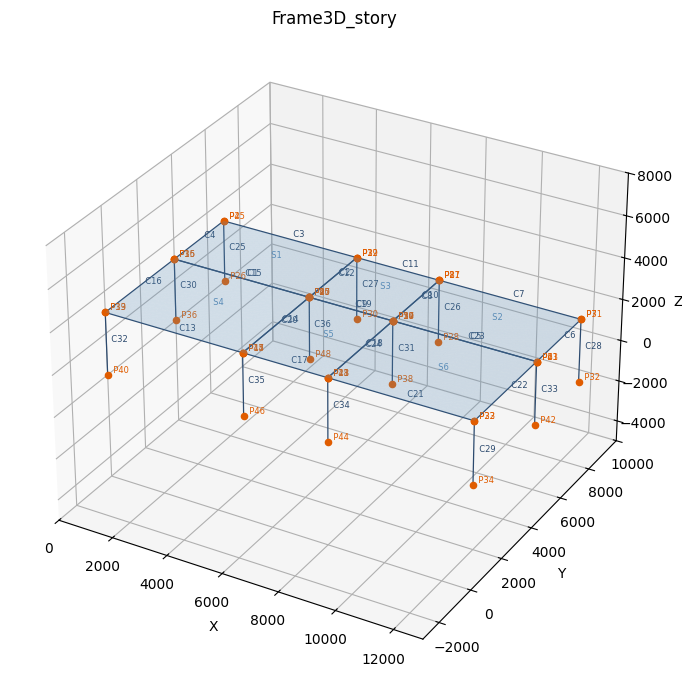

[Plot] geometry(pts=48, curves=36, surfaces=6, label_tags=False)
[Plot] label_entities(dims=[1, 2], n=42)


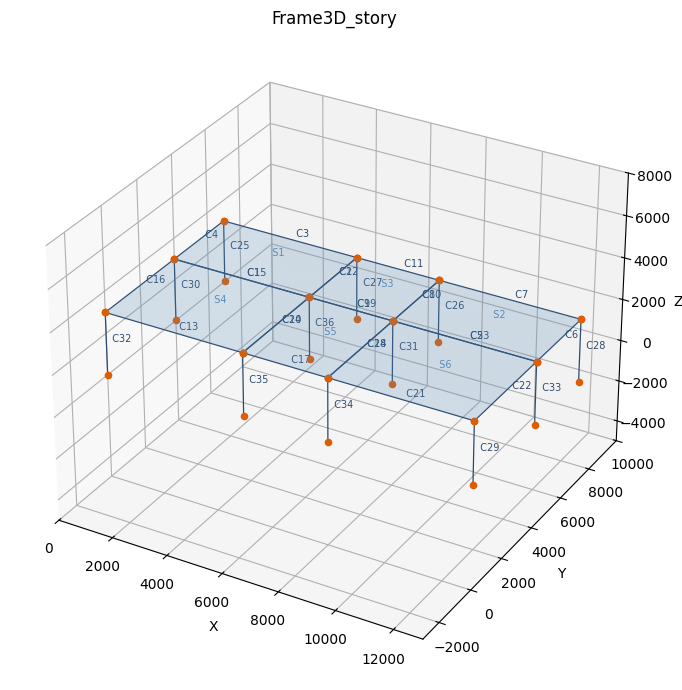

<Figure size 640x480 with 0 Axes>

In [3]:
# Quick sanity check — geometry only, no mesh yet
m1.plot.geometry(label_tags=True)

# Or layer geometry + entity labels without auto-showing between them
(m1.plot
     .geometry(show=False)
     .label_entities(dims=[1, 2])  # curves and surfaces only
     .show())

[Model] remove_duplicates(tolerance=1): merged {0: 12, 1: 7} entities (before={0: 48, 1: 36, 2: 6, 3: 0}, after={0: 36, 1: 29, 2: 6, 3: 0})
[Model] make_conformal(dims=[0, 1, 2], tolerance=1.0): entity delta={} (before={0: 36, 1: 29, 2: 6, 3: 0}, after={0: 36, 1: 29, 2: 6, 3: 0})
[Model] remove_duplicates(tolerance=1): merged {} entities (before={0: 36, 1: 29, 2: 6, 3: 0}, after={0: 36, 1: 29, 2: 6, 3: 0})
[Model] OCC kernel synchronised
[Plot] geometry(pts=36, curves=29, surfaces=6, label_tags=True)


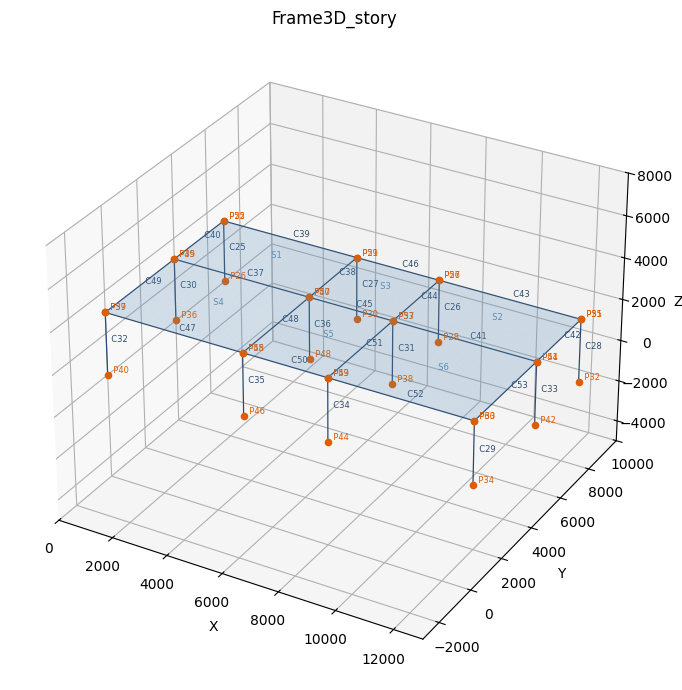

[Plot] geometry(pts=36, curves=29, surfaces=6, label_tags=False)
[Plot] label_entities(dims=[1, 2], n=35)


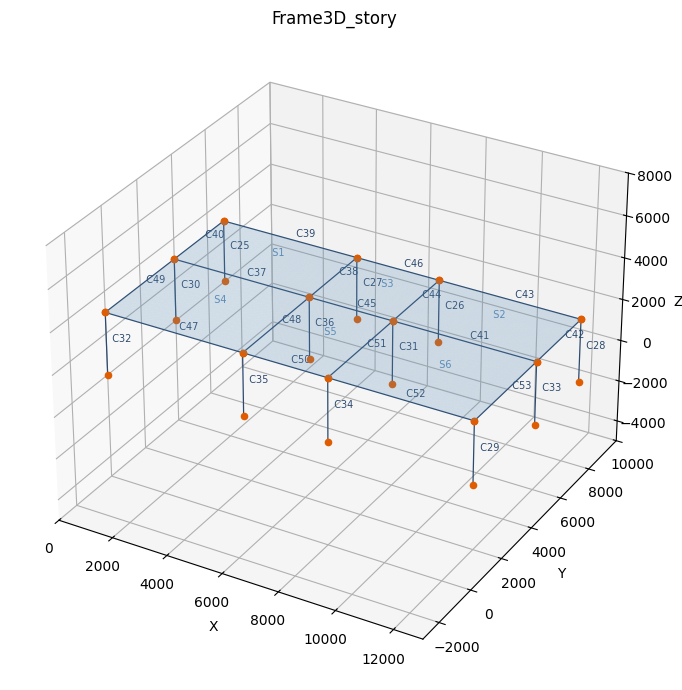

<Figure size 640x480 with 0 Axes>

In [4]:
m1.model.remove_duplicates(tolerance=1)
m1.make_conformal(tolerance=1.0)
m1.model.remove_duplicates(tolerance=1)
m1.model.sync()

# Quick sanity check — geometry only, no mesh yet
m1.plot.geometry(label_tags=True)

# Or layer geometry + entity labels without auto-showing between them
(m1.plot
     .geometry(show=False)
     .label_entities(dims=[1, 2])  # curves and surfaces only
     .show())

[Selection] select dim=0 → 12 / 36 entities
[PhysicalGroups] add(dim=0, entities=[26, 28, 30, 32, 34, 36, 38, 40, 42, 44, 46, 48]) → pg_tag=1, name='base_supports'
[Selection] select dim=1 → 12 / 29 entities
[PhysicalGroups] add(dim=1, entities=[25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]) → pg_tag=2, name='columns'
[Selection] select dim=2 → 6 / 6 entities
[PhysicalGroups] add(dim=2, entities=[1, 2, 3, 4, 5, 6]) → pg_tag=3, name='slab'
[Plot] geometry(pts=36, curves=29, surfaces=6, label_tags=False)
[Plot] physical_groups(): drew 3 group(s)


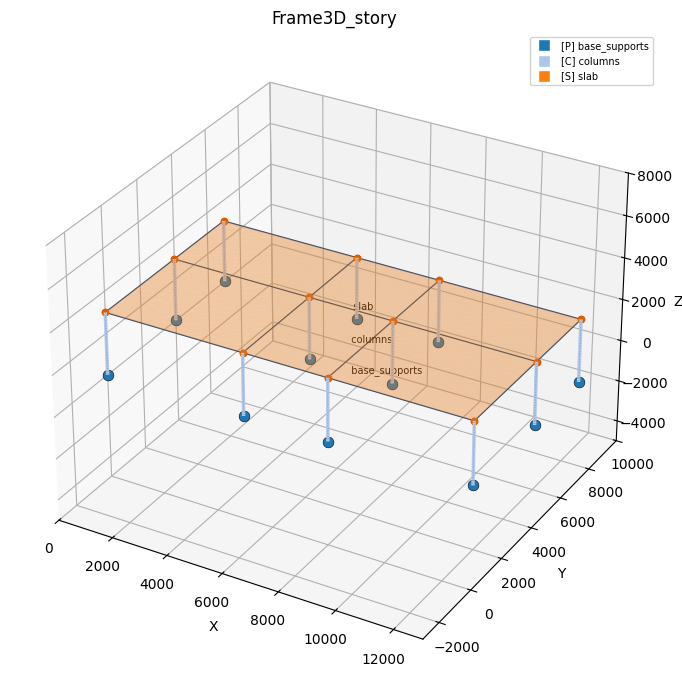

In [5]:
m1.model.selection.select_points(on_plane=("z", 0, 1e-3)).to_physical("base_supports")
m1.model.selection.select_curves(aligned="z").to_physical("columns")
m1.model.selection.select_surfaces(on_plane=("z", 3000, 1e-3)).to_physical("slab")

(m1.plot
     .geometry(show=False, surface_alpha=0.08)
     .physical_groups(show=True))

In [6]:
# m1.model.launch_picker()

In [ ]:
# Open the interactive picker — no arguments needed.
# Create / rename / delete physical groups from the toolbar, or right-click
# a group in the tree.  Everything staged during the session is written to
# Gmsh when the window is closed.
m1.model.selection.picker(
    # visual properties
    point_size=1,          # bigger node dots
    line_width=6,           # thicker curves
    surface_opacity=0.35,   # more see-through surfaces
    show_surface_edges=False,  # default — clean patches
    # sampling
    n_surf_samples=16,      # smoother surface patches
    n_curve_samples=60,     # smoother curves
)

[Mesh] set_global_size(max=2500, min=0.0)
[Mesh] generate(dim=2)
[Plot] geometry(pts=36, curves=29, surfaces=6, label_tags=False)
[Plot] mesh(): 154 polygons, 74 segments
[Plot] label_nodes(dim=-1, tag=-1, stride=2, n=129/257)
[Plot] label_elements(dim=-1, tag=-1, stride=1) → 264 labels


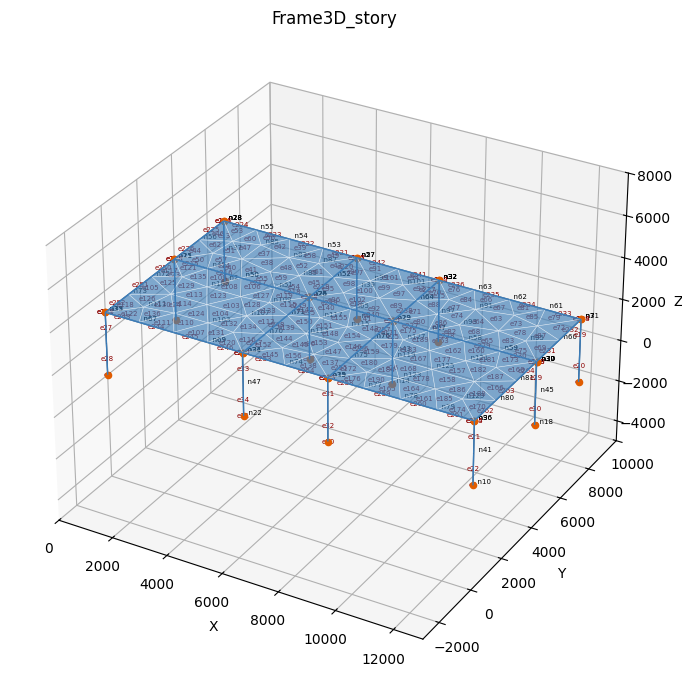

In [8]:
# 2) Global element size (model is in mm, so 250 mm ≈ 12 elems along a 3 m column)
m1.mesh.set_global_size(2500)

# 3) Generate an unstructured surface+line mesh (dim=2 covers slabs and columns)
m1.mesh.generate(dim=2)

# 5) Plot: geometry underlay + mesh overlay
(m1.plot
     .geometry(show=False)
     .mesh(alpha=0.55, linewidth=0.4, show=False)
     .label_nodes(stride=2, show=False)
     .label_elements(show=True)
     )

[Mesh] clear(dim_tags=None)
[Mesh] set_size_sources(from_points=False, from_curvature=False, extend_from_boundary=False)
[Mesh] set_global_size(max=6000, min=0.0)
[Mesh] generate(dim=2)
remove_duplicate_nodes: merged 12 node(s) (68 → 56)
[Mesh] remove_duplicate_nodes() removed=12
remove_duplicate_elements: no duplicates found (148 elements unchanged)
[Mesh] remove_duplicate_elements() removed=0
[Plot] geometry(pts=36, curves=29, surfaces=6, label_tags=False)
[Plot] mesh(): 66 polygons, 46 segments
[Plot] label_nodes(dim=-1, tag=-1, stride=1, n=104/104)
[Plot] label_elements(dim=-1, tag=-1, stride=1) → 148 labels


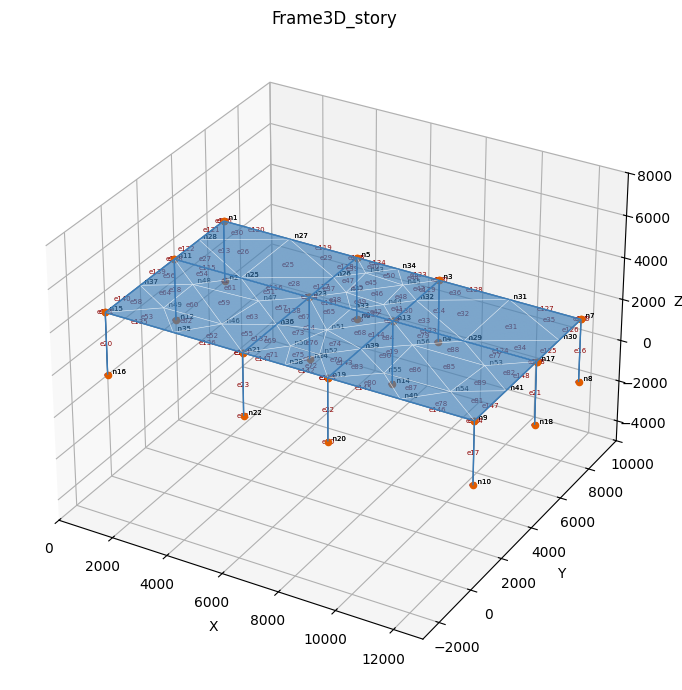

In [9]:
m1.mesh.clear()

(
     m1.mesh
          .set_size_sources(
               from_points=False,
               from_curvature=False,
               extend_from_boundary=False
          )
          .set_global_size(6000)
          .generate(dim=2)
          .remove_duplicate_nodes()
          .remove_duplicate_elements()
)


# 5) Plot: geometry underlay + mesh overlay
(m1.plot
     .geometry(show=False)
     .mesh(alpha=0.55, linewidth=0.4, show=False)
     .label_nodes(stride=0, show=False)
     .label_elements(show=True)
     )

[Mesh] clear(dim_tags=None)
[Mesh] set_size_sources(from_points=None, from_curvature=None, extend_from_boundary=True)
[Mesh] set_size_all_points(size=500, n=36)
[Mesh] set_global_size(max=6000, min=0.0)
[Mesh] generate(dim=2)
remove_duplicate_nodes: merged 12 node(s) (66 → 54)
[Mesh] remove_duplicate_nodes() removed=12
remove_duplicate_elements: no duplicates found (144 elements unchanged)
[Mesh] remove_duplicate_elements() removed=0
[Plot] geometry(pts=36, curves=29, surfaces=6, label_tags=False)
[Plot] mesh(): 62 polygons, 46 segments
[Plot] label_nodes(dim=-1, tag=-1, stride=1, n=102/102)
[Plot] label_elements(dim=-1, tag=-1, stride=1) → 144 labels


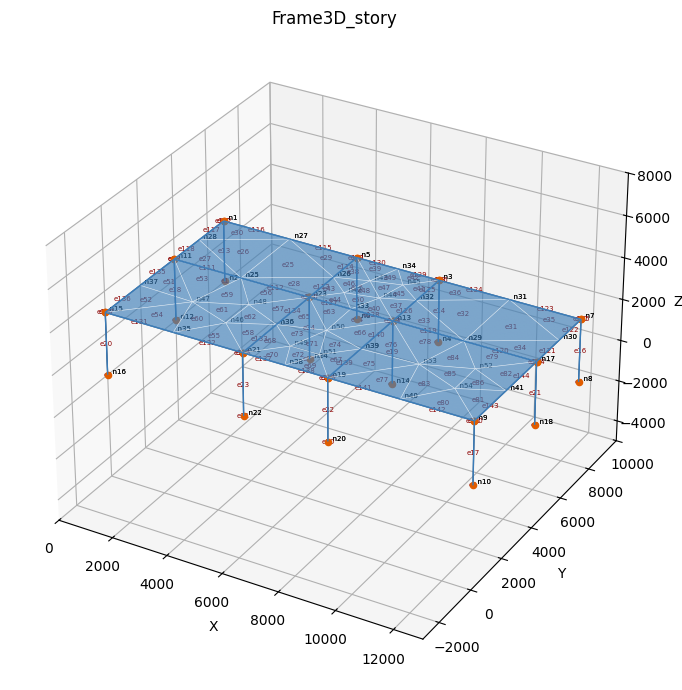

In [10]:
m1.mesh.clear()

(m1.mesh
     .set_size_sources(
          extend_from_boundary=True
     )
     .set_size_all_points(500)
     .set_global_size(6000)
     .generate(dim=2)
     .remove_duplicate_nodes()
     .remove_duplicate_elements()
     )

# 5) Plot: geometry underlay + mesh overlay
(m1.plot
     .geometry(show=False)
     .mesh(alpha=0.55, linewidth=0.4, show=False)
     .label_nodes(stride=0, show=False)
     .label_elements(show=True)
     )

[Mesh] clear(dim_tags=None)
[Selection] select dim=0 → 24 / 36 entities
Column-top nodes: [25, 27, 29, 31, 33, 35, 37, 39, 41, 43, 45, 47, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60]
[Mesh] set_size_sources(from_points=True, from_curvature=None, extend_from_boundary=True)
[Mesh] set_global_size(max=6000, min=0.0)
[Mesh] set_size(dim=0, size=500)
[Mesh] generate(dim=2)
remove_duplicate_nodes: merged 12 node(s) (579 → 567)
[Mesh] remove_duplicate_nodes() removed=12
remove_duplicate_elements: no duplicates found (1150 elements unchanged)
[Mesh] remove_duplicate_elements() removed=0
[Plot] geometry(pts=36, curves=29, surfaces=6, label_tags=False)
[Plot] mesh(): 908 polygons, 206 segments
[Plot] label_nodes(dim=0, tag=-1, stride=1, n=24/24)


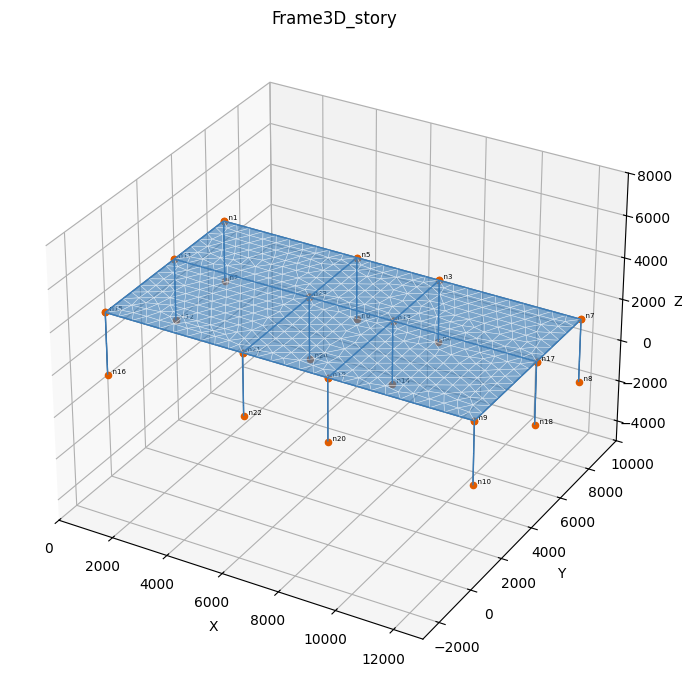

[Plot] figsize((15.0, 15.0))


In [11]:
m1.mesh.clear()

col_tops = m1.model.selection.select_points(on_plane=("z", 3000, 1e-3))
print(f"Column-top nodes: {col_tops.to_tags()}")

(m1.mesh
     .set_size_sources(from_points=True, extend_from_boundary=True)
     .set_global_size(6000)
     .set_size(col_tops.to_tags(), 500)
     .generate(dim=2)
     .remove_duplicate_nodes()
     .remove_duplicate_elements())

(m1.plot
     .geometry(show=False)
     .mesh(alpha=0.55, linewidth=0.4, show=False)
     .label_nodes(dim=0, show=True)
     .figsize((15,15)))


[Mesh] clear(dim_tags=None)
[Selection] select dim=0 → 24 / 36 entities
[Field] distance(curves=None, surfaces=None, points=[25, 27, 29, 31, 33, 35, 37, 39, 41, 43, 45, 47, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60]) → field 1
[Field] threshold(in=1, size=[300,2000], dist=[500,3000]) → field 2
[Field] set_background(field=2)
[Mesh] set_size_sources(from_points=False, from_curvature=False, extend_from_boundary=False)
[Mesh] generate(dim=2)
remove_duplicate_nodes: merged 12 node(s) (499 → 487)
[Mesh] remove_duplicate_nodes() removed=12
[Plot] geometry(pts=36, curves=29, surfaces=6, label_tags=False)
[Plot] mesh(): 732 polygons, 234 segments


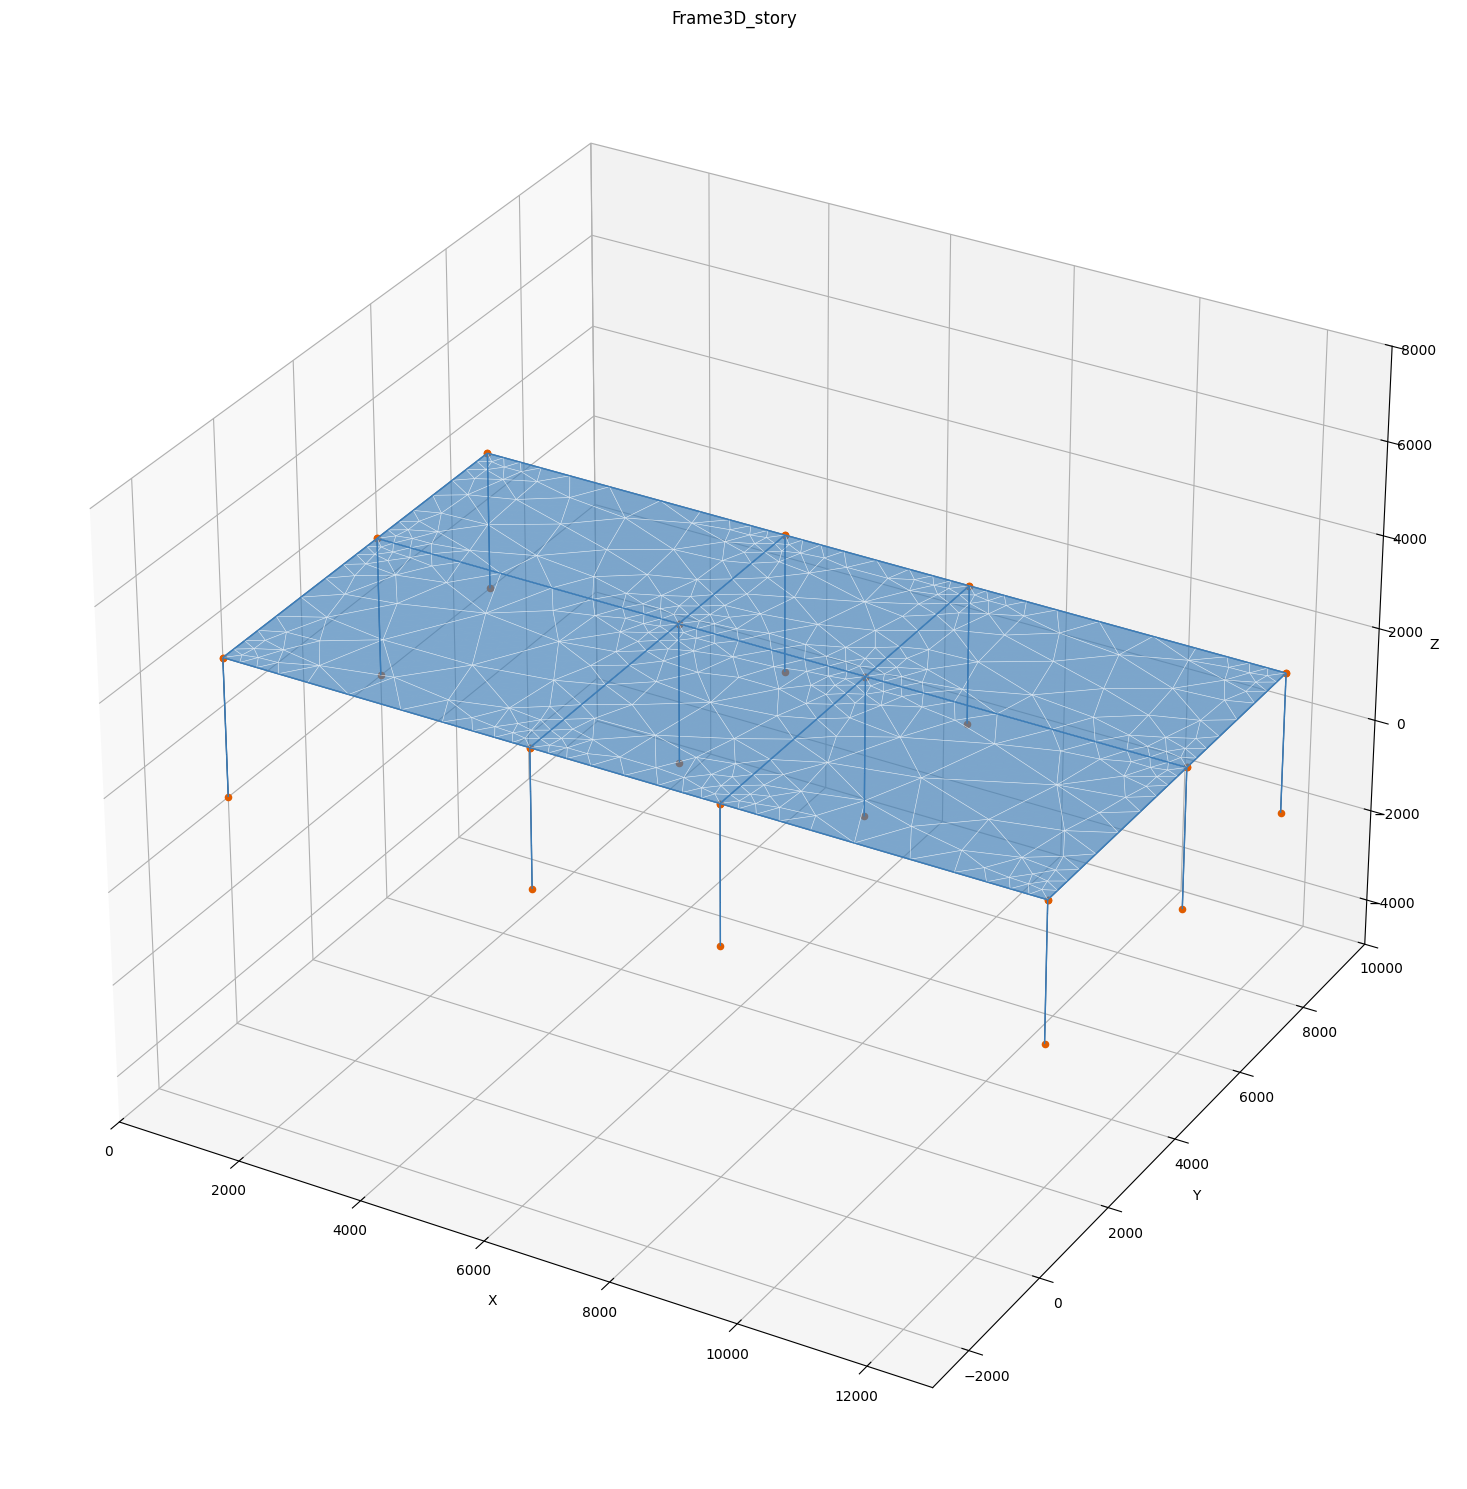

[Plot] physical_groups_mesh(): drew 3 group(s)


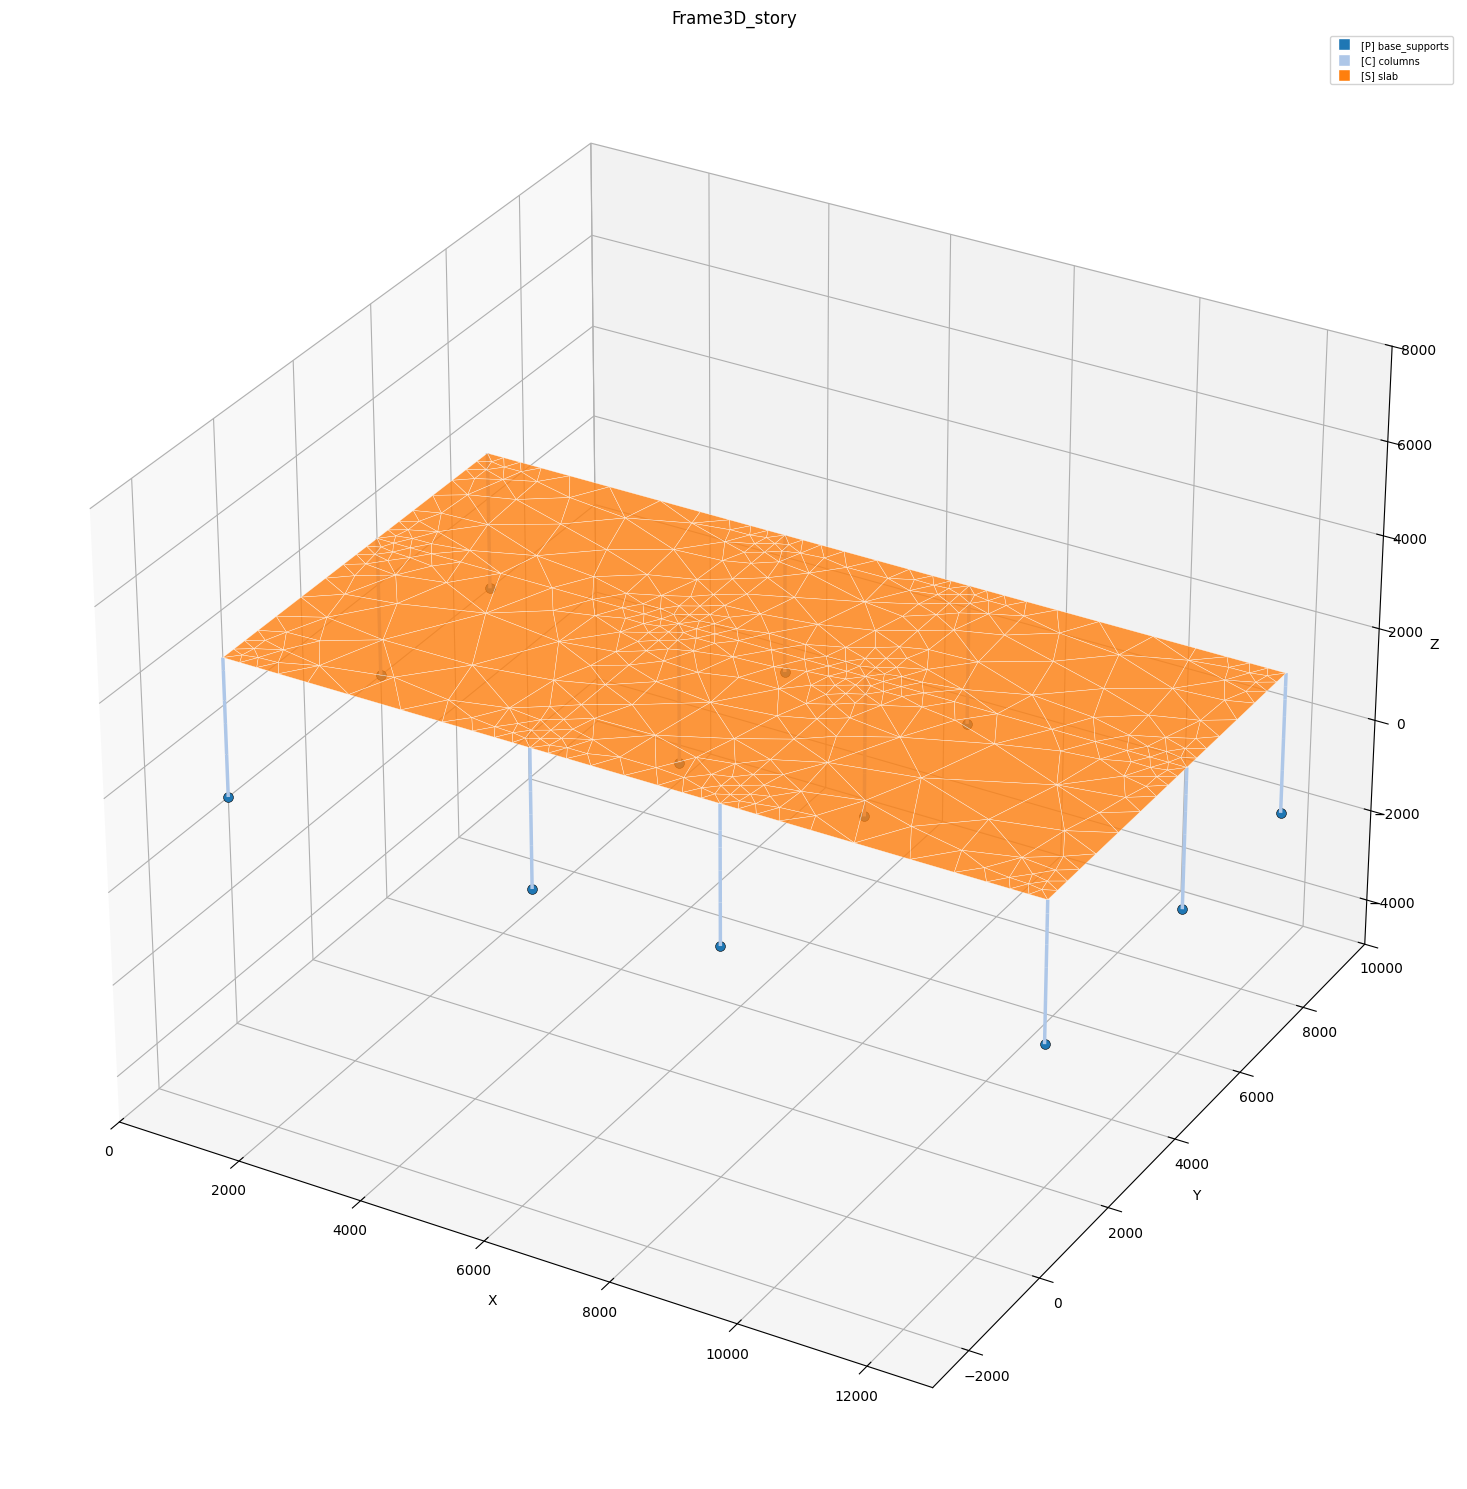

In [12]:
m1.mesh.clear()
col_tops = m1.model.selection.select_points(on_plane=("z", 3000, 1e-3))
pt_tags = col_tops.to_tags()

# 1) Distance field from the column-top points
f_dist = m1.mesh.field.distance(points=pt_tags, sampling=100)

# 2) Threshold: 300mm within 500mm → 2000mm beyond 3000mm
f_thresh = m1.mesh.field.threshold(
    f_dist,
    size_min=300,    # element size AT the column points
    size_max=2000,   # element size far from any column
    dist_min=500,    # distance at which fine → starts ramping
    dist_max=3000,   # distance at which ramp → coarse
)

# 3) Set as background mesh field — this becomes THE size source
m1.mesh.field.set_background(f_thresh)

# 4) Disable ALL point/curvature/boundary-extension sources so ONLY
#    the field drives sizing
(m1.mesh
     .set_size_sources(from_points=False,
                       from_curvature=False,
                       extend_from_boundary=False)
     .generate(dim=2)
     .remove_duplicate_nodes())

(m1.plot
     .geometry(show=False)
     .mesh(alpha=0.55, linewidth=0.4, show=True)
     .physical_groups_mesh(show=True))